In [134]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import odrpack as odr

from uncertainties import ufloat
from uncertainties.umath import *
from uncertainties import unumpy as un

import sympy as sp

In [135]:
df = pd.read_excel("p4electro.xlsx", sheet_name="h1input", decimal = ",")

In [136]:
X = un.uarray(df["I(A)"],df["dI"])
Y = un.uarray(df["B(mT)"],df["dB"])

In [137]:
def func(X, beta):
    return beta[0] * X + beta[1]

In [138]:
beta0 = [-1.6e-3,-4.81e05]

sol = odr.odr_fit(func, un.nominal_values(X), un.nominal_values(Y), beta0, weight_y = 1/(un.std_devs(Y)**2), weight_x = 1/(un.std_devs(X)**2))

print(f"pendiente = {round(sol.beta[0],3)} pm {round(np.sqrt(sol.cov_beta[0,0]),3)}")
print(f"ordenada = {round(sol.beta[1],3)} pm {round(np.sqrt(sol.cov_beta[1,1]),3)}")

pendiente = -1.627 pm 0.087
ordenada = -0.046 pm 0.086


C:\Users\Alex\Proyectos\PythonPlotting\.venv\Lib\site-packages\uncertainties\unumpy\core.py:84: FutureWarning: the uncertainties.unumpy.unumpy_to_numpy_matrix function is deprecated. It will be removed in a future release.
  warn(msg, FutureWarning)


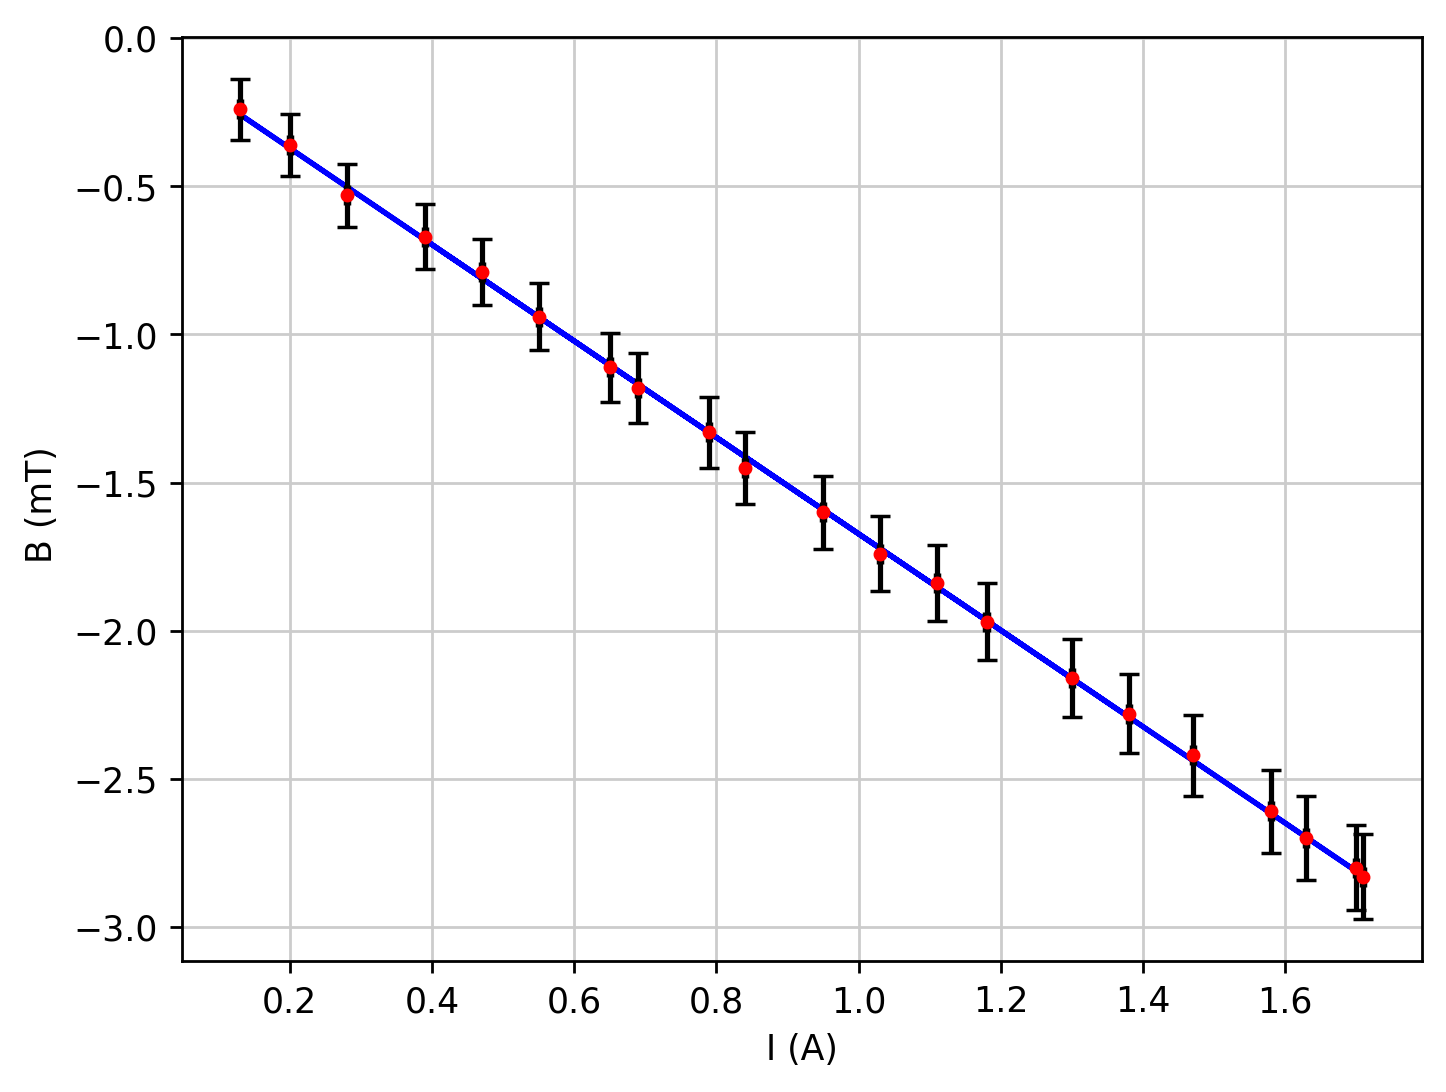

In [139]:
fig, ax = plt.subplots(dpi = 250)

ax.errorbar(un.nominal_values(X),un.nominal_values(Y), un.std_devs(X), un.std_devs(Y), color = "red", fmt = ".", ecolor = "black", capsize=3, zorder = 10)

ax.plot(un.nominal_values(X), func(un.nominal_values(X), sol.beta), color = "blue")

ax.set(xlabel = "I (A)", ylabel = "B (mT) ")

ax.grid(color = "#cccccc")


plt.show()